In [1]:
# Imports

import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [ ]:
# Settings

filename = 'kdelay.csv'
plot_width = 8
plot_height = 2
plot_sharex = True
plot_sharey = True
plot_type = sns.lineplot

In [3]:
# Parse the datafile and compute delays from timestamps
df = pd.read_csv(filename, header=0)
df["timestamp"] = df["client_schedule"] / 1000000000.0                                          # Timestamp in seconds when packet is scheduled (all others in ms)
df["send_queue_delay"] = (df["client_send_hw"] - df["client_schedule"]) / 1000000.0             # Time spent in send queue at client
df["send_kernel_delay"] = (df["client_send_hw"] - df["client_send"]) / 1000000.0                # Diff between software and hardware send timestamps (if HW supported)
df["send_net_delay"] = (df["server_recv_hw"] - df["client_send_hw"]) / 1000000.0                # Time between leaving client and arriving at server (+ clock offset)
df["recv_queue_delay"] = (df["server_process"] - df["server_recv_hw"]) / 1000000.0              # Time spent in receive queue at server
df["recv_kernel_delay"] = (df["server_recv"] - df["server_recv_hw"]) / 1000000.0                # Diff between software and hardware recv timestamps (if HW supported)
df["reply_construction_delay"] = (df["server_reply"] - df["server_process"]) / 1000000.0        # Time spent constructing reply at server
df["reply_net_delay"] = (df["reply_recv_hw"] - df["server_reply"]) / 1000000.0                  # Time between leaving server and arriving at client (- clock offset)
df["reply_queue_delay"] = (df["reply_process"] - df["reply_recv_hw"]) / 1000000.0               # Time spent in receive queue at client
df["reply_kernel_delay"] = (df["reply_recv"] - df["reply_recv_hw"]) / 1000000.0                 # Diff between software and hardware reply recv timestamps (if HW supported)
df["rtt"] = (df["reply_process"] - df["client_schedule"]) / 1000000.0                           # Total RTT, start to finish
df["queue_total"] = df["send_queue_delay"] + df["recv_queue_delay"] + df["reply_queue_delay"]   # Total time spent in queues
df["net_total"] = df["rtt"] - df["queue_total"]                                                 # Total time spent traversing the network

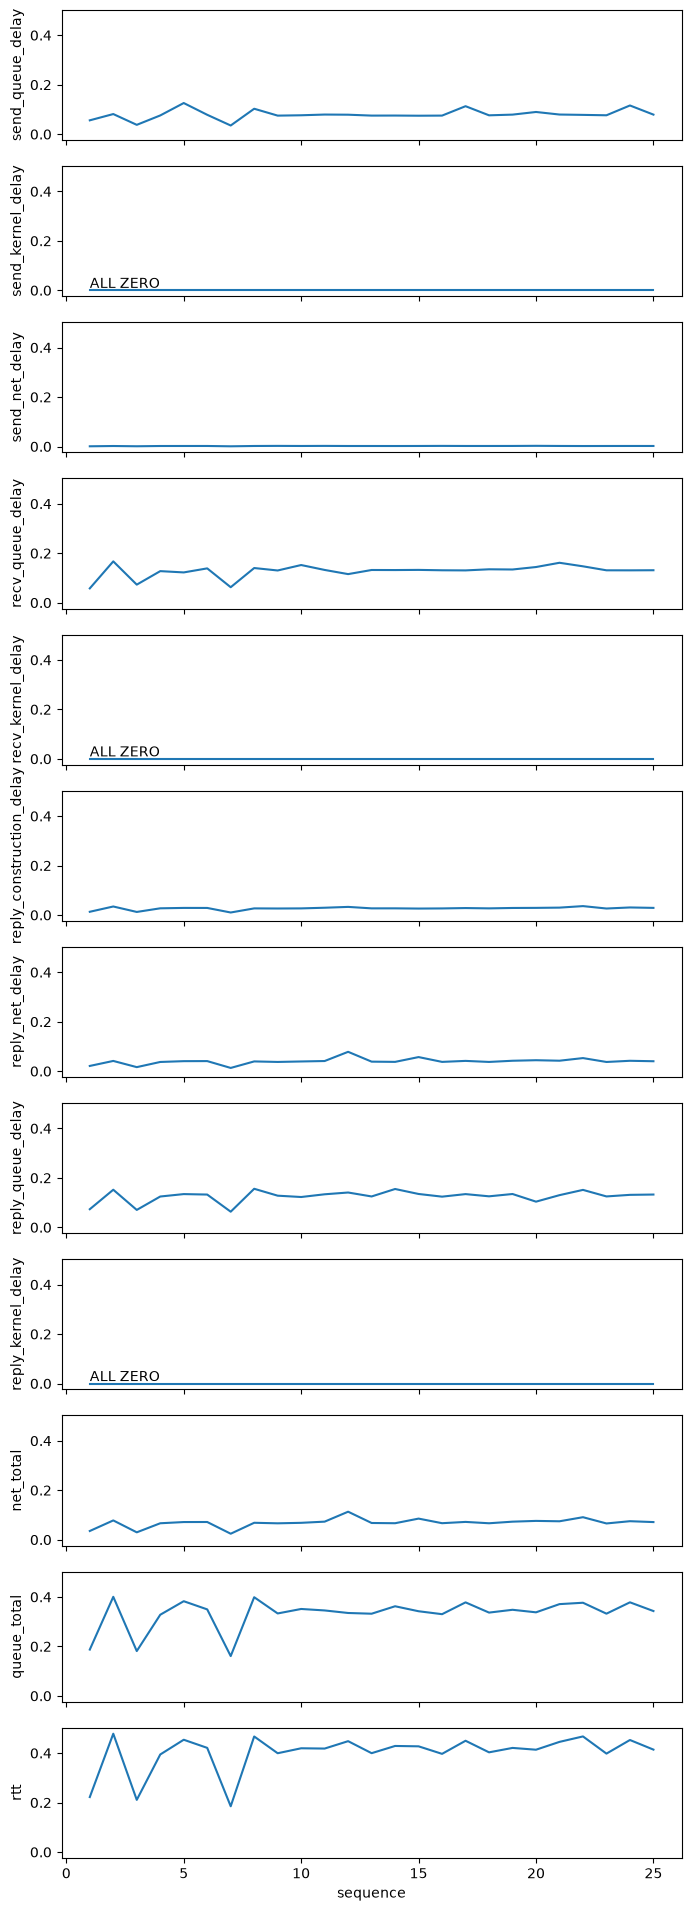

In [4]:
# Create plots

plot_vars = [
    "send_queue_delay",
    "send_kernel_delay",
    "send_net_delay",
    "recv_queue_delay",
    "recv_kernel_delay",
    "reply_construction_delay",
    "reply_net_delay",
    "reply_queue_delay",
    "reply_kernel_delay",
    "net_total",
    "queue_total",
    "rtt",
]
n_plots = len(plot_vars)

fig, axs = plt.subplots(n_plots, 1, figsize=(plot_width,plot_height*n_plots), sharex=plot_sharex, sharey=plot_sharey)
for i in range(len(plot_vars)):
    var = plot_vars[i]
    ax = axs[i]
    plot_type(ax=ax, data=df, x="sequence", y=var)
    all_zero = (df[var] == 0).all()
    if all_zero:
        ax.text(1, 0.01, "ALL ZERO")